# Lab — Statistical Testing with SciPy (Starter)

**Estimated time:** ~30 minutes  
**Tools:** Python 3, Jupyter Notebook, SciPy, Pandas, NumPy, Matplotlib

You will:
- Compute **descriptive statistics**
- Define a **hypothesis** (H₀ / H₁)
- Run a **hypothesis test** with SciPy
- **Visualise** distributions to support interpretation
- Summarise conclusions in **markdown**


## 1) Setup & Environment Check

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy
    from scipy import stats
    print("SciPy version:", scipy.__version__)
except ImportError:
    raise ImportError(
        "SciPy is not installed. Install it with:\n"
        "  - pip install scipy\n"
        "  - conda install scipy"
    )


SciPy version: 1.16.3


## 2) Load the Dataset

In [5]:
# TODO: Load dataset
# df = pd.read_csv("data/raw/experiment_results.csv")

# YOUR CODE HERE
from io import StringIO

raw_data = """participant_id,group,time_on_task_seconds
C001,control,323.7
C002,control,263.2
C003,control,343.8
C004,control,352.3
C005,control,222.2
C006,control,251.4
C007,control,315.8
C008,control,295.8
C009,control,309.2
C010,control,271.6
C011,control,349.6
C012,control,345.0
C013,control,313.0
C014,control,360.7
C015,control,331.0
C016,control,271.3
C017,control,326.6
C018,control,266.9
C019,control,349.5
C020,control,307.8
C021,control,301.7
C022,control,279.4
C023,control,365.0
C024,control,303.0
C025,control,290.7
C026,control,294.2
C027,control,334.0
C028,control,326.4
C029,control,328.6
C030,control,329.4
C031,control,406.4
C032,control,291.7
C033,control,286.9
C034,control,273.4
C035,control,337.7
C036,control,360.8
C037,control,304.9
C038,control,272.2
C039,control,272.9
C040,control,339.3
C041,control,343.4
C042,control,334.4
C043,control,280.1
C044,control,320.4
C045,control,315.3
C046,control,319.8
C047,control,349.2
C048,control,320.1
C049,control,340.6
C050,control,313.0
C051,control,323.0
C052,control,338.4
C053,control,244.4
C054,control,295.6
C055,control,288.8
C056,control,281.3
C057,control,297.6
C058,control,377.3
C059,control,271.0
C060,control,353.6
T001,treatment,254.3
T002,treatment,314.9
T003,treatment,337.3
T004,treatment,356.4
T005,treatment,362.0
T006,treatment,365.7
T007,treatment,314.3
T008,treatment,309.2
T009,treatment,368.6
T010,treatment,321.4
T011,treatment,272.6
T012,treatment,279.0
T013,treatment,288.6
T014,treatment,352.4
T015,treatment,336.4
T016,treatment,361.1
T017,treatment,310.8
T018,treatment,337.1
T019,treatment,358.2
T020,treatment,316.1
T021,treatment,350.6
T022,treatment,300.2
T023,treatment,313.7
T024,treatment,312.8
T025,treatment,276.2
T026,treatment,351.9
T027,treatment,308.9
T028,treatment,330.6
T029,treatment,351.6
T030,treatment,350.1
T031,treatment,359.9
T032,treatment,325.6
T033,treatment,311.0
T034,treatment,326.4
T035,treatment,254.1
T036,treatment,264.9
T037,treatment,270.5
T038,treatment,285.1
T039,treatment,348.0
T040,treatment,289.3
T041,treatment,313.0
T042,treatment,388.5
T043,treatment,314.0
T044,treatment,363.2
T045,treatment,288.0
T046,treatment,320.8
T047,treatment,287.2
T048,treatment,314.7
T049,treatment,367.8
T050,treatment,252.3
T051,treatment,349.5
T052,treatment,340.7
T053,treatment,303.3
T054,treatment,264.9
T055,treatment,333.2
T056,treatment,306.2
T057,treatment,340.5
T058,treatment,331.0
T059,treatment,402.1
T060,treatment,319.2"""



In [6]:
# TODO: Preview + basic checks
# df.head()
# df.info()

# YOUR CODE HEREdf = pd.read_csv(StringIO(raw_data))
print(f"Shape: {df.shape}")
print(f"Groups: {df['group'].unique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(10)


Shape: (120, 3)
Groups: ['control' 'treatment']
Missing values: 0


,participant_id,group,time_on_task_seconds
0,C001,control,323.7
1,C002,control,263.2
2,C003,control,343.8
3,C004,control,352.3
4,C005,control,222.2
5,C006,control,251.4
6,C007,control,315.8
7,C008,control,295.8
8,C009,control,309.2
9,C010,control,271.6


## 3) Compute Descriptive Statistics

In [7]:
# TODO: Overall descriptive stats
# df["time_on_task_seconds"].describe()

# YOUR CODE HERE
print("=== Overall Descriptive Stats ===")
print(df["time_on_task_seconds"].describe().round(2))

=== Overall Descriptive Stats ===
count    120.00
mean     317.28
std       35.13
min      222.20
25%      290.35
50%      317.65
75%      343.50
max      406.40
Name: time_on_task_seconds, dtype: float64


In [9]:
# TODO: Grouped descriptive stats
# df.groupby("group")["time_on_task_seconds"].agg(["count", "mean", "std", "min", "max"])

# YOUR CODE HERE
print("\n=== Descriptive Stats by Group ===")
print(df.groupby("group")["time_on_task_seconds"].agg(
    ["count", "mean", "std", "min", "max"]).round(2))



=== Descriptive Stats by Group ===
           count    mean    std    min    max
group                                        
control       60  312.94  35.35  222.2  406.4
treatment     60  321.63  34.66  252.3  402.1


## 4) Define Your Hypothesis

### Hypothesis

- **H₀ (null):**  
- **H₁ (alternative):**  
- **Significance level (α):** 0.05  


## 5) Perform a Hypothesis Test (SciPy)

In [10]:
# TODO: Split into two arrays
# control = df.loc[df["group"] == "control", "time_on_task_seconds"].to_numpy()
# treatment = df.loc[df["group"] == "treatment", "time_on_task_seconds"].to_numpy()

# YOUR CODE HEREprint
control   = df.loc[df["group"] == "control",
                   "time_on_task_seconds"].to_numpy()
treatment = df.loc[df["group"] == "treatment",
                   "time_on_task_seconds"].to_numpy()
print(f"Control:   n={len(control)},  "
      f"mean={control.mean():.2f}s,  std={control.std():.2f}s")
print(f"Treatment: n={len(treatment)}, "
      f"mean={treatment.mean():.2f}s,  std={treatment.std():.2f}s")



Control:   n=60,  mean=312.94s,  std=35.06s
Treatment: n=60, mean=321.63s,  std=34.37s


In [11]:
# TODO: Run Welch's t-test (recommended when variances may differ)
# t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
# print("t statistic:", t_stat)
# print("p-value:", p_value)

# YOUR CODE HERE
t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n→ Reject H₀: The difference IS statistically significant (p < {alpha})")
else:
    print(f"\n→ Fail to reject H₀: No significant difference found (p ≥ {alpha})")


t-statistic: 1.3602
p-value:     0.1764

→ Fail to reject H₀: No significant difference found (p ≥ 0.05)


## 6) Visualise the Data

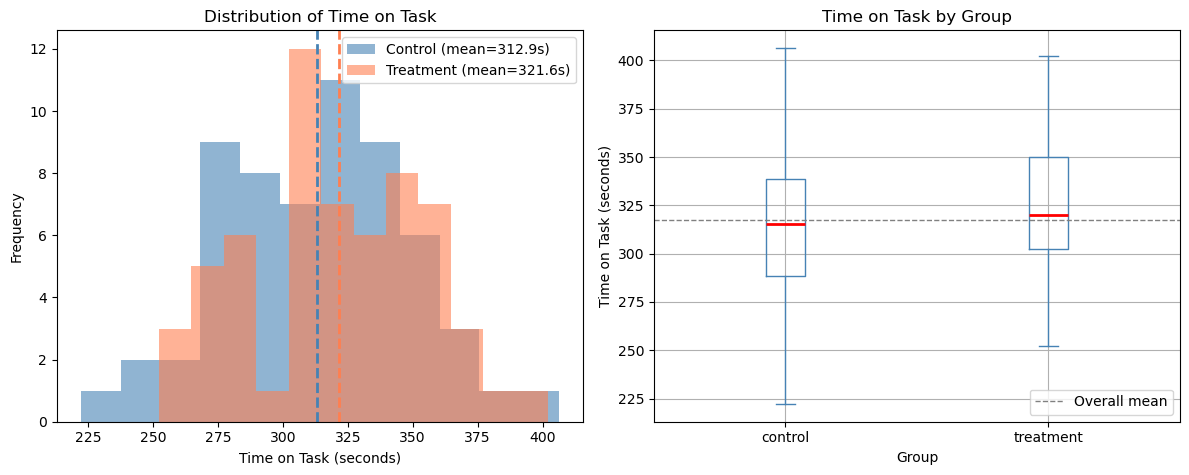

In [15]:
# TODO: Create at least ONE plot (boxplot or histogram) to compare groups.
# Tip: A boxplot is often a quick, clear comparison.

# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(control,   bins=12, alpha=0.6, color="steelblue",
             label=f"Control (mean={control.mean():.1f}s)")
axes[0].hist(treatment, bins=12, alpha=0.6, color="coral",
             label=f"Treatment (mean={treatment.mean():.1f}s)")
axes[0].axvline(control.mean(),   color="steelblue",
                linestyle="--", linewidth=2)
axes[0].axvline(treatment.mean(), color="coral",
                linestyle="--", linewidth=2)
axes[0].set_title("Distribution of Time on Task")
axes[0].set_xlabel("Time on Task (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
df.boxplot(column="time_on_task_seconds", by="group", ax=axes[1],
           boxprops=dict(color="steelblue"),
           medianprops=dict(color="red", linewidth=2),
           whiskerprops=dict(color="steelblue"),
           capprops=dict(color="steelblue"),
           flierprops=dict(marker="o", color="steelblue", alpha=0.5))
axes[1].set_title("Time on Task by Group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Time on Task (seconds)")
axes[1].axhline(df["time_on_task_seconds"].mean(),
                color="gray", linestyle="--",
                linewidth=1, label="Overall mean")
axes[1].legend()
plt.suptitle("")

plt.tight_layout()
plt.show()

## 7) Interpret and Document Results

### Results & Interpretation

- **Test used:**  
- **t statistic:**  
- **p-value:**  
- **Decision (α = 0.05):**  
- **Plain-language conclusion:**  

**Assumptions / limitations:**  
-  
